#Mini Project (Stock Market Price Prediction)

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Internship/NIELIT/NIELIT Datasets/Tesla_dataset.csv')
df

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,58.803165,17187100,23.830000
2,07-01-2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,07-02-2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,07-06-2010,20.000000,20.000000,15.830000,51.337992,6866900,16.110001
...,...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,265.793784,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,268.126491,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,265.346220,7100400,262.049988


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1608 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1608 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1608.000000,1692.000000,1692.000000,1608.000000,1.692000e+03,1692.000000
mean,133.157257,134.769698,129.996223,131.987988,4.270741e+06,132.428658
std,94.319131,95.694914,92.855227,94.802670,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,-11.088631,1.185000e+05,15.800000
25%,30.067500,30.650000,29.215000,30.003727,1.194350e+06,29.884999
50%,162.764999,162.370002,153.150002,154.324997,3.180700e+06,158.160004
75%,220.672497,224.099999,217.119999,220.500000,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,291.318872,3.716390e+07,286.040009


#Data Preprocessing


In [ ]:
df.isnull().sum()

,0
Date,0
Open,84
High,0
Low,0
Close,84
Volume,0
Adj Close,0


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

#Removing Outliers

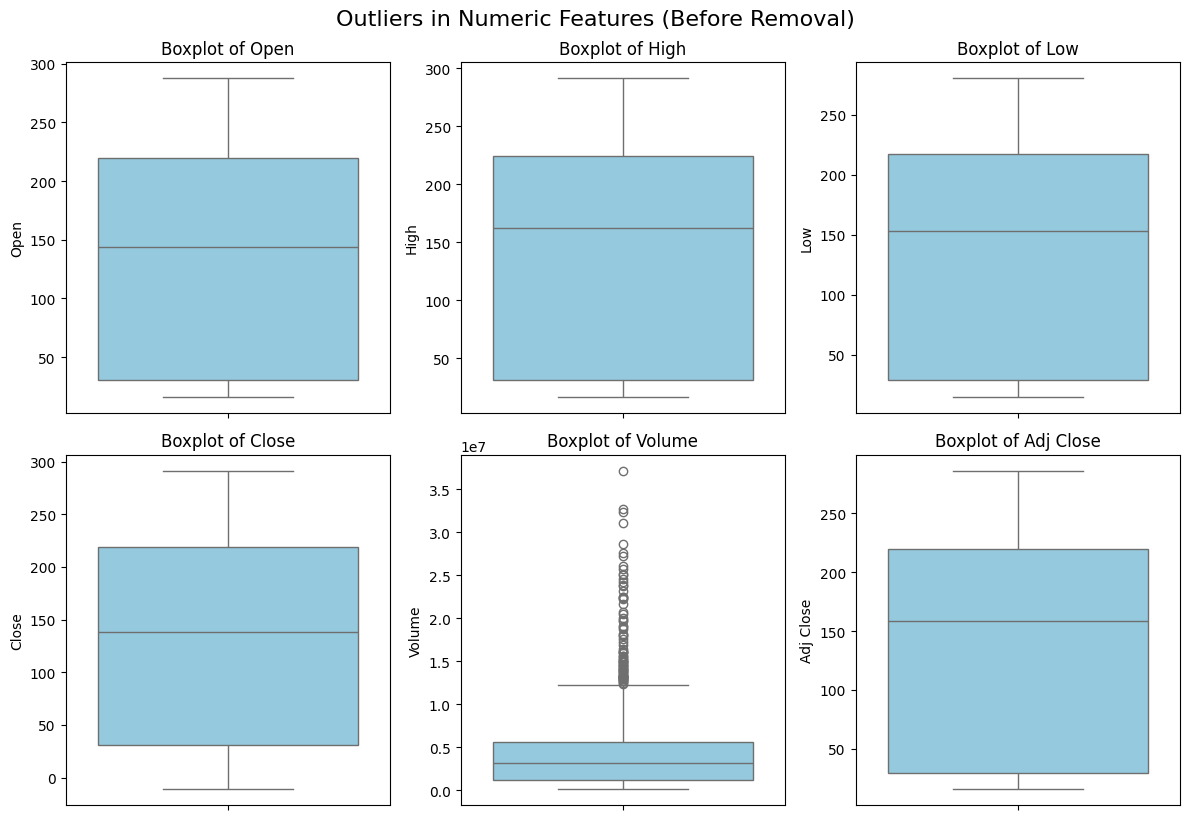

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.suptitle("Outliers in Numeric Features (Before Removal)", fontsize=16, y=1.02)
plt.show()


In [ ]:

def remove_outliers_iqr(df):
    df_clean = df.copy()
    numeric_cols = df_clean.select_dtypes(include='number').columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

df_no_outliers = remove_outliers_iqr(df)

print("Shape before outlier removal:", df.shape)
print("Shape after outlier removal:", df_no_outliers.shape)

Shape before outlier removal: (1692, 7)
Shape after outlier removal: (1612, 7)


#Seperating Independent and Dependent Variables

In [ ]:
x = df.drop(['Date','Close','Adj Close'],axis=1)
x

,Open,High,Low,Volume
0,19.000000,25.000000,17.540001,18766300
1,25.790001,30.420000,23.299999,17187100
2,25.000000,25.920000,20.270000,8218800
3,23.000000,23.100000,18.709999,5139800
4,20.000000,20.000000,15.830000,6866900
...,...,...,...,...
1687,244.820007,246.850006,242.779999,3010700
1688,246.110001,258.119995,246.020004,7575500
1689,257.000000,261.000000,254.270004,4816600
1690,262.399994,265.750000,259.059998,7100400


In [ ]:
y = df['Close']
y

,Close
0,23.889999
1,58.803165
2,21.959999
3,19.200001
4,51.337992
...,...
1687,246.169998
1688,265.793784
1689,268.126491
1690,265.346220


#Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2, random_state=42)

#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain, ytrain)

y_pred=model.predict(xtest)
y_pred

array([199.80016576, 216.09984977, 223.84011089, 196.4323868 ,
       221.90157586,  24.99096889, 195.37822101, 187.3465405 ,
       229.08449497,  25.32579366,  37.46658682,  35.82402045,
        25.42400797, 195.35477659,  25.2913902 ,  41.79696133,
        35.80089029,  32.97627613, 197.14122835, 211.46437691,
        49.16516879, 225.15329691,  39.83259695, 271.16609214,
       209.25102005,  32.729245  , 234.69623384, 218.47301735,
        38.18621603, 244.21373135, 205.03891829,  30.92742613,
       185.3559349 ,  32.80395244,  32.97743616, 146.97921589,
        32.21943632,  33.16834735,  33.44724925, 202.02701966,
        25.57898408,  33.63496011,  37.52266439, 218.97981275,
       193.01317474, 162.09276113,  34.57460415,  37.98904528,
        26.73931739, 246.77844635,  37.40141198, 248.5347025 ,
        35.70117309,  32.90629329, 191.75762641,  32.76173144,
       221.68016777, 245.94201262, 200.92873204, 125.40074472,
       240.29953339,  32.24671781, 213.98446822, 213.63

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(ytest, y_pred)

mse = mean_squared_error(ytest, y_pred)

r2 = r2_score(ytest, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 10.39034734505794
Mean Squared Error: 530.3372882750053
R² Score: 0.9406075461831384


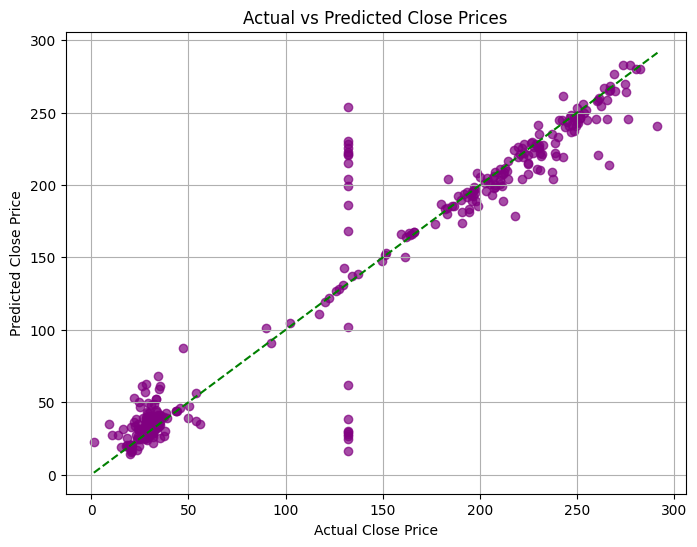

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred, color='purple', alpha=0.7)
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], color='green', linestyle='--', label='Ideal Line (y = x)')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Prices")
plt.grid(True)
plt.show()

#Decision Tree Regressoion

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(xtrain, ytrain)

y_pred = model.predict(xtest)
y_pred

array([200.699997  , 236.62647307, 228.490005  , 197.809998  ,
       225.589996  ,  19.940001  , 193.639999  , 188.020004  ,
       236.889999  ,  21.        ,  33.130001  ,  31.379999  ,
        -1.66299098, 190.88915267,  20.23      ,  38.16      ,
        32.66      ,  38.80527728, 234.37382062, 221.309998  ,
        43.93      , 229.869995  ,  38.14047313, 284.119995  ,
       131.98798846, 131.98798846, 131.98798846, 226.699997  ,
        33.529999  , 251.080002  , 216.5       ,  27.57      ,
       191.169998  ,  28.4       ,  28.76      , 147.        ,
        27.549999  ,  28.530001  ,  19.33445702, 203.779999  ,
        20.719999  ,  29.139999  ,  33.07      , 220.990005  ,
       194.940002  , 165.539993  ,  30.059999  ,  34.529999  ,
       131.98798846, 250.020004  ,  33.150002  , 251.929993  ,
        31.27      , 131.98798846, 193.149994  ,  26.66      ,
       225.589996  , 247.710007  , 208.789993  , 127.9381094 ,
       247.369995  ,  27.6       , 219.070007  , 217.75

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(ytest, y_pred)

mse = mean_squared_error(ytest, y_pred)

r2 = r2_score(ytest, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 15.428725086364745
Mean Squared Error: 1163.4055718811512
R² Score: 0.8697102518984099


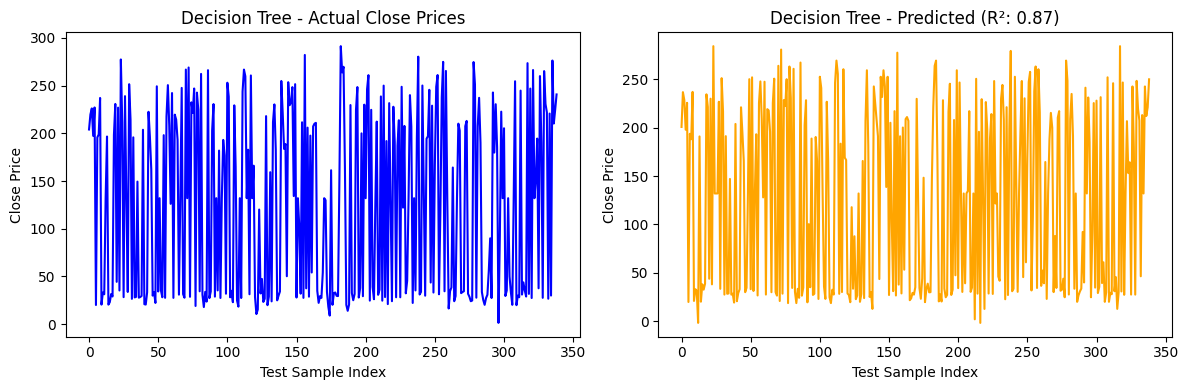

In [ ]:
plt.figure(figsize=(12, 4))

# Actual
plt.subplot(1, 2, 1)
plt.plot(ytest.values, color='blue')
plt.title("Decision Tree - Actual Close Prices")
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price")

# Predicted
plt.subplot(1, 2, 2)
plt.plot(y_pred, color='orange')
plt.title(f"Decision Tree - Predicted (R²: {r2_score(ytest, y_pred):.2f})")
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price")

plt.tight_layout()
plt.show()

#Random Forest Regressoion

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)

y_pred = model.predict(xtest)
y_pred

array([202.17620809, 225.96652279, 228.6785719 , 194.18337547,
       221.78198139,  20.1342003 , 195.19810143, 185.8011471 ,
       235.27527663,  15.573623  ,  52.0625365 ,  28.92049047,
        16.53590452, 195.79917794,  19.54407027,  38.72726872,
        33.97698747,  36.49791929, 208.58367206, 210.32069437,
        43.68534989, 229.35635485,  60.8849399 , 282.82069981,
       188.8228724 ,  62.6955084 , 219.98226928, 220.80992578,
        32.87551323, 248.30345504, 204.46093966,  25.28825004,
       188.99820745,  30.53659889,  42.96535218, 147.29152867,
        24.65472838,  38.59485852,  27.8393468 , 204.78188293,
        20.72179936,  33.12266788,  33.79182167, 222.3564431 ,
       192.51737812, 164.11369723,  30.2429163 ,  40.53846289,
        53.0900296 , 240.4837122 ,  35.774705  , 253.68317279,
        34.55421953,  31.14348795, 188.73438832,  27.73630708,
       223.81258647, 242.67932473, 199.96486846, 126.54037542,
       245.13645704,  57.27793834, 219.21546604, 216.77

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(ytest, y_pred)

mse = mean_squared_error(ytest, y_pred)

r2 = r2_score(ytest, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 11.935422516357702
Mean Squared Error: 614.6392386544245
R² Score: 0.9311665737957985


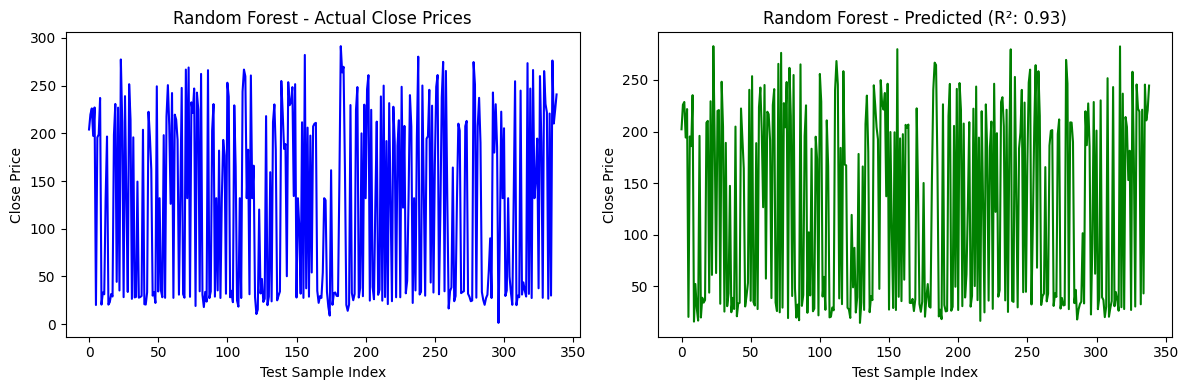

In [ ]:
plt.figure(figsize=(12, 4))

# Actual
plt.subplot(1, 2, 1)
plt.plot(ytest.values, color='blue')
plt.title("Random Forest - Actual Close Prices")
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price")

#Predicted
plt.subplot(1, 2, 2)
plt.plot(y_pred, color='green')
plt.title(f"Random Forest - Predicted (R²: {r2_score(ytest, y_pred):.2f})")
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price")

plt.tight_layout()
plt.show()